In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from google.colab import files
import os

# 1. Botón para cargar archivos
# NOTA: Selecciona TODOS los archivos asociados al shapefile (.shp, .shx, .dbf, .prj)
print("Sube todos los archivos asociados al Shapefile (.shp, .shx, .dbf, etc.)")
uploaded = files.upload()

# 2. Identificar el nombre del archivo .shp
file_name = [f for f in uploaded.keys() if f.endswith('.shp')][0]

# 3. Leer el archivo con GeoPandas
try:
    gdf = gpd.read_file(file_name)
    print(f"Archivo {file_name} cargado exitosamente.")

    # Mostrar las primeras filas de la tabla de atributos
    display(gdf.head())

    # 4. Visualización
    fig, ax = plt.subplots(figsize=(12, 10))

    # Graficamos los datos de edafología
    # 'column' puede ser una categoría como 'DESCRIPCIO' o 'CLAVE' si deseas colores distintos
    gdf.plot(ax=ax, cmap='terrain', edgecolor='black', linewidth=0.1)

    plt.title(f'Visualización de Edafología: {file_name}', fontsize=15)
    plt.xlabel('Longitud')
    plt.ylabel('Latitud')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.show()

except Exception as e:
    print(f"Error al procesar el archivo: {e}")

Sube todos los archivos asociados al Shapefile (.shp, .shx, .dbf, etc.)


Saving cdv_edaf_esc_250k_serie II_cont_nac.dbf to cdv_edaf_esc_250k_serie II_cont_nac.dbf
Saving cdv_edaf_esc_250k_serie II_cont_nac.shp to cdv_edaf_esc_250k_serie II_cont_nac (1).shp
Saving cdv_edaf_esc_250k_serie II_cont_nac.shp.xml to cdv_edaf_esc_250k_serie II_cont_nac.shp.xml
Saving cdv_edaf_esc_250k_serie II_cont_nac.shx to cdv_edaf_esc_250k_serie II_cont_nac.shx
Error al procesar el archivo: Unable to open cdv_edaf_esc_250k_serie II_cont_nac (1).shx or cdv_edaf_esc_250k_serie II_cont_nac (1).SHX. Set SHAPE_RESTORE_SHX config option to YES to restore or create it.


Available columns in gdf_nacional:
Index(['CLAVE_WRB', 'GRUPO1', 'CALIFS_G1', 'CALIFP_G1', 'GRUPO2', 'CALIFS_G2',
       'CALIFP_G2', 'GRUPO3', 'CALIFS_G3', 'CALIFP_G3', 'CLASE_TEX', 'FRUDICA',
       'N_G1', 'N_CS_G1', 'N_CP_G1', 'N_G2', 'N_CS_G2', 'N_CP_G2', 'N_G3',
       'N_CS_G3', 'N_CP_G3', 'TEXTURA', 'F_SUPERF', 'TIP_INFO', 'CAL_POS',
       'geometry'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


Archivo completo guardado con éxito como edafologia_nacional_completa.shp.


<Axes: >

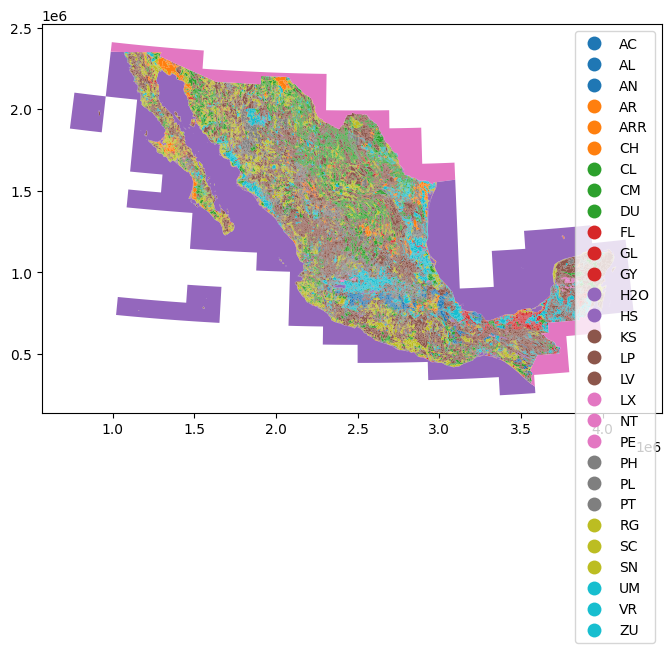

In [5]:
import geopandas as gpd

# 1. Leer el archivo nacional (requiere .shp, .shx y .dbf en la misma carpeta)
file_path = 'cdv_edaf_esc_250k_serie II_cont_nac.shp'
gdf_nacional = gpd.read_file(file_path)

# Display available columns to identify the correct municipality column
print("Available columns in gdf_nacional:")
print(gdf_nacional.columns)

# The column 'NOM_MUN' was not found in the GeoDataFrame.
# Therefore, the municipality filtering section will be skipped.
# If you have another column for municipal data, please replace 'NOM_MUN' with the correct column name.
# municipios_veracruz = ['Veracruz', 'Boca del Río', 'Medellín']
# zona_estudio = gdf_nacional[gdf_nacional['NOM_MUN'].isin(municipios_veracruz)]

# 3. Guardar el archivo (guardaremos el GeoDataFrame completo ya que no se pudo filtrar por municipio)
gdf_nacional.to_file("edafologia_nacional_completa.shp")
print("Archivo completo guardado con éxito como edafologia_nacional_completa.shp.")

# 4. Visualización rápida
# Using 'GRUPO1' for visualization as 'DESCRIPCIO' was not found.
# You can change 'GRUPO1' to any other column from the list printed above if you prefer.
gdf_nacional.plot(figsize=(8, 8), column='GRUPO1', legend=True)

### Aislamiento de la zona geográfica de interés (Veracruz y Boca del Río)

### Intersectar con los datos de Edafología para obtener solo la zona de interés

Asignando el CRS del TIF a los datos de edafología.


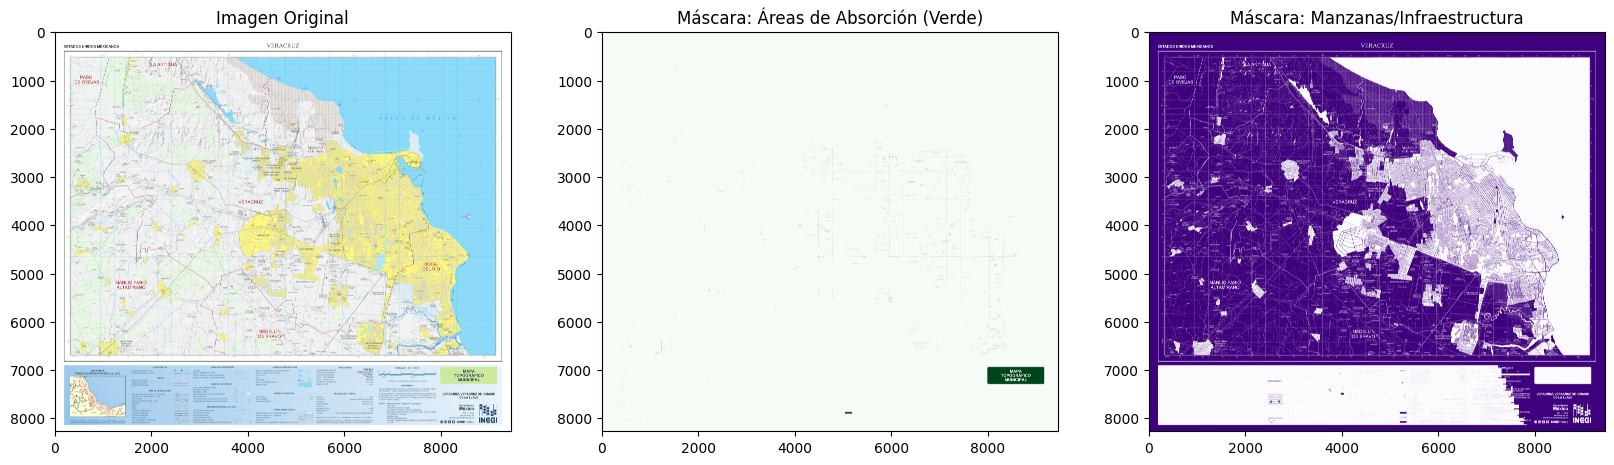

Análisis completado. Datos de edafología cargados con 75491 registros.


In [11]:
import cv2
import numpy as np
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show

# 1. Cargar el mapa georreferenciado
path_tif = 'mapa_veracruz_georeferenciado.tif'
with rasterio.open(path_tif) as src:
    img_raster = src.read([1, 2, 3]).transpose(1, 2, 0) # Leer bandas RGB
    transform = src.transform
    crs = src.crs

# 2. Segmentación por Color (OpenCV)
hsv = cv2.cvtColor(img_raster, cv2.COLOR_RGB2HSV)

# Rangos ajustados para áreas verdes (absorción) y manzanas (flujo)
verde_bajo = np.array([35, 40, 40])
verde_alto = np.array([85, 255, 255])
urbano_bajo = np.array([0, 0, 200]) # Tonos claros/grisáceos
urbano_alto = np.array([180, 30, 255])

mask_verde = cv2.inRange(hsv, verde_bajo, verde_alto)
mask_urbano = cv2.inRange(hsv, urbano_bajo, urbano_alto)

# 3. Cargar datos de Edafología (Shapefiles)
# Usamos el archivo 'edafologia_nacional_completa.shp'
path_shp = 'edafologia_nacional_completa.shp'
edafologia_data = gpd.read_file(path_shp)

# Assign a CRS to edafologia_data if it's missing (naive geometries).
# We assume it's already in the same CRS as the TIF but lacks metadata.
if edafologia_data.crs is None:
    print("Asignando el CRS del TIF a los datos de edafología.")
    edafologia_data = edafologia_data.set_crs(crs)

# Asegurar que el Shapefile use el mismo sistema de coordenadas que el TIF
edafologia_data = edafologia_data.to_crs(crs)

# 4. Visualización de control en Colab
fig, ax = plt.subplots(1, 3, figsize=(20, 10))

ax[0].imshow(img_raster)
ax[0].set_title("Imagen Original")

ax[1].imshow(mask_verde, cmap='Greens')
ax[1].set_title("Máscara: Áreas de Absorción (Verde)")

ax[2].imshow(mask_urbano, cmap='Purples')
ax[2].set_title("Máscara: Manzanas/Infraestructura")

plt.show()

# 5. Exportar resultados segmentados
cv2.imwrite('absorcion_segmentada.png', mask_verde)
cv2.imwrite('manzanas_segmentadas.png', mask_urbano)

print(f"Análisis completado. Datos de edafología cargados con {len(edafologia_data)} registros.")